# Identify relative bakery under-provision across London MSOAs

This notebook identifies the MSOAs which have lower observed bakery provision than expected under the final income-extended Negative Binomial models.

Core bakeries and bakery cafés are used as the primary definition of bakery provision as it provided the best balance between classification agreement and coverage in the final validation.

Two sensitivity definitions are retained:
- core bakeries only as a stricter definition
- all provision including grocer and supermarket bakeries as a broader definition

The primary core-and-café results are presented first, followed by the strict and broad sensitivity results.

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

DATA_DATE = "2026-07-23"
EXPECTED_MSOAS = 1002

SPATIAL_PROCESSED_FOLDER = Path("../data/spatial/processed")
MODEL_OUTPUT_FOLDER = Path("../outputs/models")

TABLE_FOLDER = Path("../outputs/tables")
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_DATA_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_income_model_predictions_{DATA_DATE}.csv")
MODEL_COMPARISON_PATH = (TABLE_FOLDER / f"income_model_comparison_{DATA_DATE}.csv")
MSOA_PATH = (SPATIAL_PROCESSED_FOLDER / "london_msoa_2021.gpkg")

print(f"Model data found: {MODEL_DATA_PATH.exists()}")
print(f"Model comparison found: {MODEL_COMPARISON_PATH.exists()}")
print(f"MSOA boundaries found: {MSOA_PATH.exists()}")

Model data found: True
Model comparison found: True
MSOA boundaries found: True


## Load final model results and MSOA boundaries

In [3]:
model_data = pd.read_csv(MODEL_DATA_PATH,
                         dtype={"msoa_code": "string"},
                         low_memory=False)

model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
msoa_boundaries = gpd.read_file(MSOA_PATH)

msoa_boundaries["msoa_code"] = (msoa_boundaries["msoa_code"]
                                .astype("string")
                                .str.strip())

print(f"Model rows: {len(model_data)}")
print(f"MSOA boundary rows: {len(msoa_boundaries)}")

display(model_comparison[["Definition", "Income model AIC", "Income model alpha"]].round(3))

Model rows: 1002
MSOA boundary rows: 1002


,Definition,Income model AIC,Income model alpha
0,Core only,2548.875,1.080
1,Core and café,4127.116,1.088
2,All provision included,5205.474,0.662


In [4]:
required_columns = ["msoa_code",
                    "msoa_name",
                    "borough_code",
                    "borough_name",
                    "area_km2",
                    "population",
                    "transport_nodes",
                    "income_bhc",
                    "core_bakery_count",
                    "core_and_cafe_count",
                    "bakery_count",
                    "income_expected_core_bakery_count",
                    "income_expected_core_and_cafe_count",
                    "income_expected_bakery_count"]

missing_columns = [column for column in required_columns
                   if column not in model_data.columns]

if missing_columns:
    raise KeyError(f"Missing model columns: {missing_columns}")

expected_columns = ["income_expected_core_bakery_count",
                    "income_expected_core_and_cafe_count",
                    "income_expected_bakery_count"]

print(f"Expected MSOAs: {EXPECTED_MSOAS}")
print(f"Model rows: {len(model_data)}")
print(f"Duplicate model MSOAs: {model_data['msoa_code'].duplicated().sum()}")
print(f"Missing expected values: {model_data[expected_columns].isna().sum().sum()}")
print(f"Duplicate boundary MSOAs: {msoa_boundaries['msoa_code'].duplicated().sum()}")
print(f"Missing geometries: {msoa_boundaries['geometry'].isna().sum()}")

Expected MSOAs: 1002
Model rows: 1002
Duplicate model MSOAs: 0
Missing expected values: 0
Duplicate boundary MSOAs: 0
Missing geometries: 0


## Calculate relative under-provision

Raw shortfall is calculated as the model-expected establishment count minus the observed count.

In [5]:
definition_settings = {"Core only": {"prefix": "core",
                                     "observed": "core_bakery_count",
                                     "expected": "income_expected_core_bakery_count"},
                       "Core and café": {"prefix": "core_cafe",
                                         "observed": "core_and_cafe_count",
                                         "expected": "income_expected_core_and_cafe_count"},
                       "All provision included": {"prefix": "all",
                                                  "observed": "bakery_count",
                                                  "expected": "income_expected_bakery_count"}}

alpha_lookup = (model_comparison
                .set_index("Definition")["Income model alpha"]
                .to_dict())

analysis_data = model_data.copy()

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]
    observed = analysis_data[settings["observed"]]
    expected = analysis_data[settings["expected"]]
    alpha = alpha_lookup[definition]

    variance = expected + alpha * expected ** 2

    analysis_data[f"{prefix}_raw_shortfall"] = (expected - observed)
    analysis_data[f"{prefix}_standardised_shortfall"] = ((expected - observed) / np.sqrt(variance))
    analysis_data[f"{prefix}_underprovision_percentile"] = (analysis_data[f"{prefix}_standardised_shortfall"]
                                                            .rank(method="average", pct=True) * 100)
    analysis_data[f"{prefix}_underprovision_rank"] = (analysis_data[f"{prefix}_standardised_shortfall"]
                                                      .rank(method="min", ascending=False)
                                                      .astype(int))
    analysis_data[f"{prefix}_top_decile"] = (analysis_data[f"{prefix}_underprovision_percentile"] >= 90)

print("Under-provision scores calculated for all three definitions.")

Under-provision scores calculated for all three definitions.


In [6]:
definition_roles = {"Core only": "Strict sensitivity",
                    "Core and café": "Primary definition",
                    "All provision included": "Broad sensitivity"}

score_summary_rows = []

for definition, settings in definition_settings.items():
    prefix = settings["prefix"]
    observed = analysis_data[settings["observed"]]
    expected = analysis_data[settings["expected"]]

    raw_shortfall = analysis_data[f"{prefix}_raw_shortfall"]
    standardised = analysis_data[f"{prefix}_standardised_shortfall"]

    score_summary_rows.append({"Definition": definition,
                               "Role": definition_roles[definition],
                               "Observed establishments": observed.sum(),
                               "Expected establishments": expected.sum(),
                               "MSOAs below expectation": (raw_shortfall > 0).sum(),
                               "Median raw shortfall": raw_shortfall.median(),
                               "Highest standardised shortfall": standardised.max()})

score_summary = pd.DataFrame(score_summary_rows)

display(score_summary.round({"Expected establishments": 1,
                             "Median raw shortfall": 2,
                             "Highest standardised shortfall": 2}))

,Definition,Role,Observed establishments,Expected establishments,MSOAs below expectation,Median raw shortfall,Highest standardised shortfall
0,Core only,Strict sensitivity,925,907.0,625,0.46,0.81
1,Core and café,Primary definition,2928,2800.9,652,0.76,0.90
2,All provision included,Broad sensitivity,5178,5079.5,624,1.00,1.14


## Primary under-provision ranking

MSOAs are ranked by their standardised shortfall, higher values indicate that observed bakery provision is further below the model-expected count.

In [7]:
primary_definition = "Core and café"
primary_settings = definition_settings[primary_definition]

primary_prefix = primary_settings["prefix"]
primary_observed = primary_settings["observed"]
primary_expected = primary_settings["expected"]

primary_top_areas = (analysis_data
                     .sort_values(f"{primary_prefix}_standardised_shortfall", ascending=False)
                     .head(20)[["msoa_code",
                                "msoa_name",
                                "borough_name",
                                primary_observed,
                                primary_expected,
                                f"{primary_prefix}_raw_shortfall",
                                f"{primary_prefix}_standardised_shortfall",
                                f"{primary_prefix}_underprovision_rank"]].copy())

primary_top_areas = primary_top_areas.rename(
    columns={primary_observed: "Observed count",
             primary_expected: "Expected count",
             f"{primary_prefix}_raw_shortfall": "Raw shortfall",
             f"{primary_prefix}_standardised_shortfall": "Standardised shortfall",
             f"{primary_prefix}_underprovision_rank": "Rank"})

display(primary_top_areas.round({"Expected count": 2,
                                 "Raw shortfall": 2,
                                 "Standardised shortfall": 4}))

,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
222,E02000234,Croydon 041,Croydon,0,7.14,7.14,0.9026,1
939,E02006789,Bromley 042,Bromley,0,6.11,6.11,0.8939,2
140,E02000147,Bromley 021,Bromley,0,5.78,5.78,0.8907,3
766,E02000814,Southwark 008,Southwark,0,5.77,5.77,0.8906,4
215,E02000227,Croydon 034,Croydon,0,5.46,5.46,0.8870,5
28,E02000030,Barnet 007,Barnet,0,5.16,5.16,0.8835,6
224,E02000236,Croydon 043,Croydon,0,4.97,4.97,0.8808,7
752,E02000798,Richmond upon Thames 015,Richmond upon Thames,0,4.95,4.95,0.8806,8
219,E02000231,Croydon 038,Croydon,0,4.92,4.92,0.8802,9
208,E02000219,Croydon 026,Croydon,0,4.91,4.91,0.8800,10


## Strict and broad sensitivity rankings

The primary ranking is compared with the two alternative definitions.

The ten highest-ranked MSOAs are displayed for each sensitivity definition, while the complete top-20 tables are retained for saving.

In [8]:
sensitivity_definitions = ["Core only", "All provision included"]

sensitivity_tables = []

for definition in sensitivity_definitions:
    settings = definition_settings[definition]

    prefix = settings["prefix"]
    observed_column = settings["observed"]
    expected_column = settings["expected"]

    sensitivity_table = (analysis_data
                         .sort_values(f"{prefix}_standardised_shortfall", ascending=False)
                         .head(20)[["msoa_code",
                                    "msoa_name",
                                    "borough_name",
                                    observed_column,
                                    expected_column,
                                    f"{prefix}_raw_shortfall",
                                    f"{prefix}_standardised_shortfall",
                                    f"{prefix}_underprovision_rank"]].copy())

    sensitivity_table.insert(0, "Definition", definition)

    sensitivity_table = sensitivity_table.rename(
        columns={observed_column: "Observed count",
                 expected_column: "Expected count",
                 f"{prefix}_raw_shortfall": "Raw shortfall",
                 f"{prefix}_standardised_shortfall": "Standardised shortfall",
                 f"{prefix}_underprovision_rank": "Rank"})

    sensitivity_tables.append(sensitivity_table)

    print(f"\n{definition}")
    display(sensitivity_table
            .drop(columns="Definition")
            .head(10)
            .round({"Expected count": 2,
                    "Raw shortfall": 2,
                    "Standardised shortfall": 2}))

sensitivity_top_areas = pd.concat(sensitivity_tables, ignore_index=True)


Core only


,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
841,E02000890,Tower Hamlets 027,Tower Hamlets,0,2.33,2.33,0.81,1
939,E02006789,Bromley 042,Bromley,0,2.31,2.31,0.81,2
999,E02007113,Tower Hamlets 035,Tower Hamlets,0,2.28,2.28,0.81,3
963,E02006941,Southwark 035,Southwark,0,2.22,2.22,0.81,4
222,E02000234,Croydon 041,Croydon,0,2.21,2.21,0.81,5
126,E02000132,Bromley 006,Bromley,0,2.10,2.10,0.80,6
739,E02000785,Richmond upon Thames 002,Richmond upon Thames,0,2.04,2.04,0.80,7
155,E02000162,Bromley 036,Bromley,0,2.02,2.02,0.80,8
215,E02000227,Croydon 034,Croydon,0,1.86,1.86,0.79,9
28,E02000030,Barnet 007,Barnet,0,1.73,1.73,0.78,10



All provision included


,msoa_code,msoa_name,borough_name,Observed count,Expected count,Raw shortfall,Standardised shortfall,Rank
766,E02000814,Southwark 008,Southwark,0,9.48,9.48,1.14,1
140,E02000147,Bromley 021,Bromley,0,8.78,8.78,1.14,2
219,E02000231,Croydon 038,Croydon,0,7.91,7.91,1.13,3
80,E02000084,Bexley 020,Bexley,0,7.91,7.91,1.13,4
735,E02000781,Redbridge 031,Redbridge,0,7.47,7.47,1.12,5
844,E02000895,Waltham Forest 001,Waltham Forest,0,6.69,6.69,1.11,6
243,E02000255,Ealing 018,Ealing,0,6.64,6.64,1.11,7
223,E02000235,Croydon 042,Croydon,0,6.61,6.61,1.11,8
607,E02000640,Lambeth 023,Lambeth,0,6.51,6.51,1.11,9
500,E02000532,Hounslow 007,Hounslow,0,6.40,6.40,1.11,10


In [15]:
core_top = analysis_data["core_top_decile"]
primary_top = analysis_data["core_cafe_top_decile"]
broad_top = analysis_data["all_top_decile"]

print(f"Primary vs core top decile: {(primary_top & core_top).sum() / primary_top.sum():.1%}")
print(f"Primary vs all provision top decile: {(primary_top & broad_top).sum() / primary_top.sum():.1%}")
print(f"Core vs all provision top decile: {(core_top & broad_top).sum() / core_top.sum():.1%}")

Primary vs core top decile: 34.7%
Primary vs all provision top decile: 37.6%
Core vs all provision top decile: 18.8%


## Map the primary under-provision result

The primary standardised shortfall is mapped using Red MSOAs as those with under-provision and Blue as those with more provision than expected (black boundaries identify the 20 highest-ranked MSOAs).

Black boundaries show the 20 highest-ranked MSOAs.


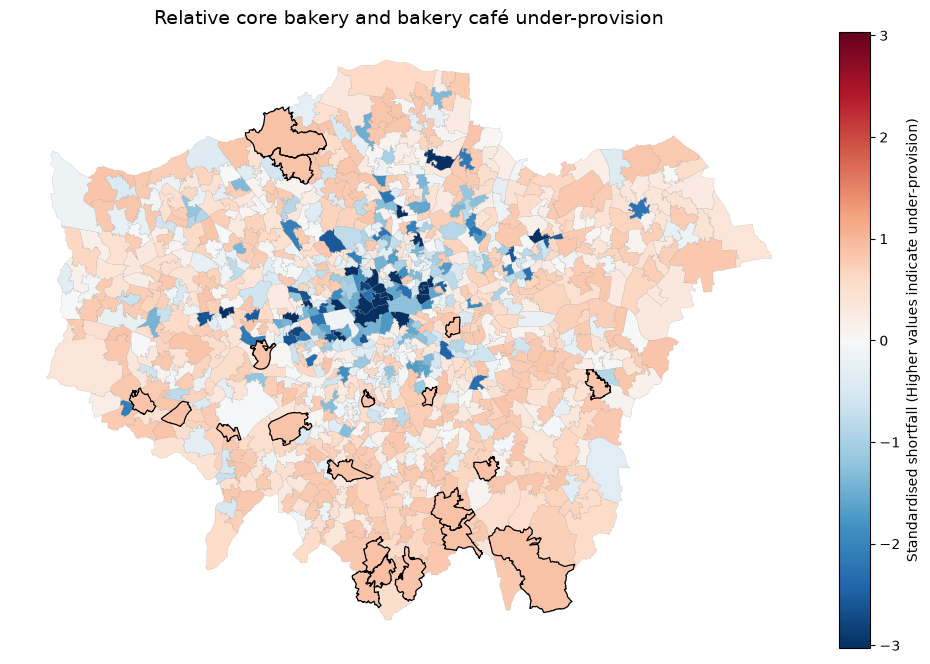

Saved to: ..\outputs\figures\msoa_core_cafe_underprovision_2026-07-23.png


In [9]:
from matplotlib.colors import TwoSlopeNorm


primary_map_data = (msoa_boundaries[["msoa_code","geometry"]]
                    .merge(analysis_data[["msoa_code",
                                           "core_cafe_standardised_shortfall",
                                           "core_cafe_underprovision_rank"]],
                                           on="msoa_code",
                                           how="left",
                                           validate="one_to_one"))

primary_scores = (primary_map_data["core_cafe_standardised_shortfall"]
                  .dropna()
                  .to_numpy())

primary_colour_limit = np.quantile(np.abs(primary_scores), 0.98)

primary_colour_limit = max(primary_colour_limit, 1)

primary_colour_norm = TwoSlopeNorm(vmin=-primary_colour_limit,
                                   vcenter=0,
                                   vmax=primary_colour_limit)

primary_highest_ranked = (primary_map_data[primary_map_data
                                           ["core_cafe_underprovision_rank"] <= 20])

fig, axis = plt.subplots(figsize=(20, 8))

primary_map_data.plot(column="core_cafe_standardised_shortfall",
                      cmap="RdBu_r",
                      norm=primary_colour_norm,
                      linewidth=0.1,
                      edgecolor="grey",
                      ax=axis)

primary_highest_ranked.boundary.plot(color="black", linewidth=0.9, ax=axis)

colour_scale = plt.cm.ScalarMappable(norm=primary_colour_norm, cmap="RdBu_r")

colour_bar = fig.colorbar(colour_scale,
                          ax=axis,
                          fraction=0.035,
                          pad=0.02)

colour_bar.set_label("Standardised shortfall (Higher values indicate under-provision)")

axis.set_title("Relative core bakery and bakery café under-provision", fontsize=14)

axis.axis("off")

PRIMARY_MAP_PATH = (FIGURE_FOLDER / f"msoa_core_cafe_underprovision_{DATA_DATE}.png")
plt.savefig(PRIMARY_MAP_PATH, dpi=300,  bbox_inches="tight")
print("Black boundaries show the 20 highest-ranked MSOAs.")

plt.show()

print(f"Saved to: {PRIMARY_MAP_PATH}")

# Map boroguh context for primary result

Boroguh boundaries are added to the MSOA-level under-provision map for geographic context, but without removing the within borough variation that can be seen from smaller statistical areas.

Dark lines show borough boundaries.
Green lines show the 20 highest-ranked MSOAs.


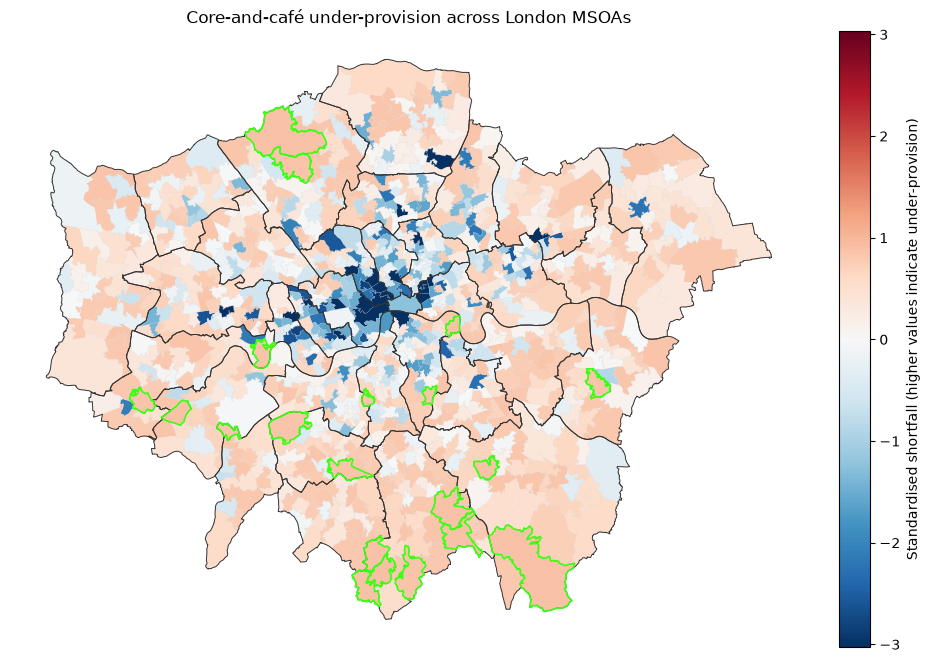

Saved to: ..\outputs\figures\msoa_core_cafe_underprovision_2026-07-23.png


In [10]:
primary_map_data = (msoa_boundaries[["msoa_code", "borough_name", "geometry"]]
    .merge(analysis_data[["msoa_code",
                          "core_cafe_standardised_shortfall",
                          "core_cafe_underprovision_rank"]],
                          on="msoa_code",
                          how="left",
                          validate="one_to_one"))

borough_boundaries = (primary_map_data.dissolve(by="borough_name"))

fig, axis = plt.subplots(figsize=(20, 8))

primary_map_data.plot(column="core_cafe_standardised_shortfall",
                      cmap="RdBu_r",
                      norm=primary_colour_norm,
                      linewidth=0.1,
                      edgecolor="lightgrey",
                      ax=axis)

borough_boundaries.boundary.plot(color="#333333",
                                 linewidth=0.7,
                                 ax=axis)

primary_highest_ranked.boundary.plot(color="#39FF14",
                                     linewidth=1.2,
                                     ax=axis)

colour_scale = plt.cm.ScalarMappable(norm=primary_colour_norm,
                                     cmap="RdBu_r")

colour_bar = fig.colorbar(colour_scale,
                          ax=axis,
                          fraction=0.035,
                          pad=0.02)

colour_bar.set_label("Standardised shortfall (higher values indicate under-provision)")

axis.set_title("Core-and-café under-provision across London MSOAs")
axis.axis("off")

PRIMARY_MAP_PATH = (FIGURE_FOLDER / f"msoa_core_cafe_underprovision_{DATA_DATE}.png")

plt.savefig(PRIMARY_MAP_PATH, dpi=300, bbox_inches="tight")

print("Dark lines show borough boundaries.")
print("Green lines show the 20 highest-ranked MSOAs.")

plt.show()

print(f"Saved to: {PRIMARY_MAP_PATH}")

In [11]:
borough_variation = (analysis_data
                     .groupby("borough_name")
                     .agg(MSOAs=("msoa_code", "count"),
                          Mean_shortfall=("core_cafe_standardised_shortfall", "mean"),
                          Shortfall_SD=("core_cafe_standardised_shortfall", "std"),
                          Minimum_shortfall=("core_cafe_standardised_shortfall", "min"),
                          Maximum_shortfall=("core_cafe_standardised_shortfall", "max"),
                          Top_decile_MSOAs=("core_cafe_top_decile", "sum"))
                          .reset_index())

borough_variation["Shortfall_range"] = (borough_variation["Maximum_shortfall"] - borough_variation["Minimum_shortfall"])

borough_variation = borough_variation.sort_values("Shortfall_range", ascending=False)

BOROUGH_VARIATION_PATH = (TABLE_FOLDER / f"core_cafe_borough_variation_{DATA_DATE}.csv")

borough_variation.to_csv(BOROUGH_VARIATION_PATH, index=False, encoding="utf-8-sig")

display(borough_variation.round(3))

,borough_name,MSOAs,Mean_shortfall,Shortfall_SD,Minimum_shortfall,Maximum_shortfall,Top_decile_MSOAs,Shortfall_range
29,Tower Hamlets,34,-0.814,2.469,-10.314,0.822,1,11.135
19,Kensington and Chelsea,21,-1.504,2.198,-9.840,0.798,0,10.638
32,Westminster,24,-1.409,2.360,-9.160,0.780,0,9.940
5,Camden,27,-1.527,2.420,-7.441,0.814,1,8.255
27,Southwark,34,-0.264,1.120,-4.427,0.891,6,5.317
9,Enfield,36,0.110,0.900,-3.930,0.843,5,4.773
25,Redbridge,33,0.211,0.898,-3.370,0.826,2,4.196
11,Hackney,30,-0.406,0.928,-3.209,0.827,1,4.036
12,Hammersmith and Fulham,25,-0.598,1.202,-3.164,0.861,1,4.025
8,Ealing,41,0.043,0.985,-3.129,0.856,3,3.985


## Map the sensitivity definitions

These maps assess how the geographical pattern changes when a narrower or broader definition of bakery provision is applied.

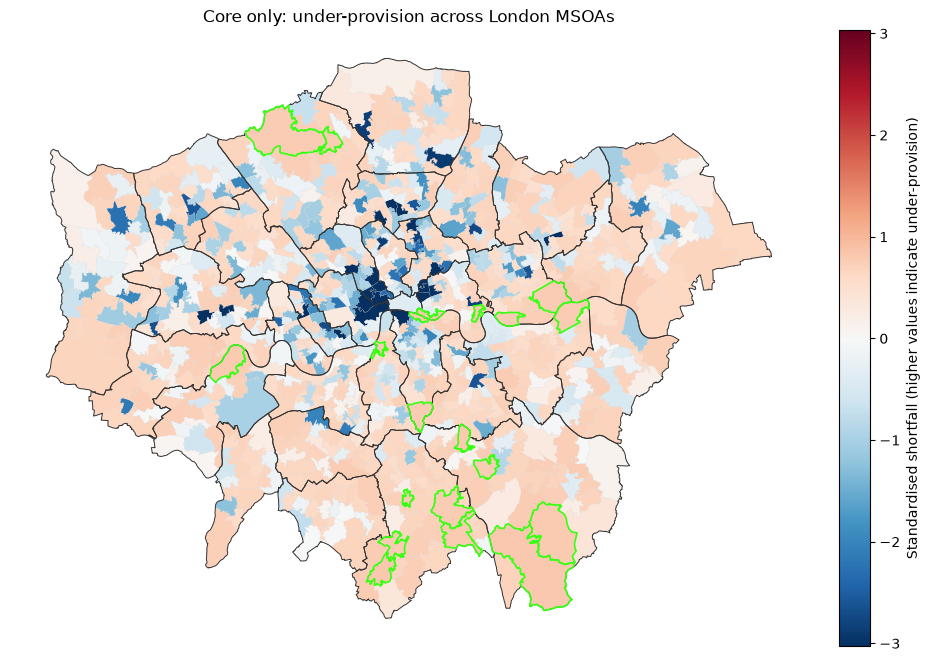

Saved to: ..\outputs\figures\msoa_core_only_underprovision_2026-07-23.png


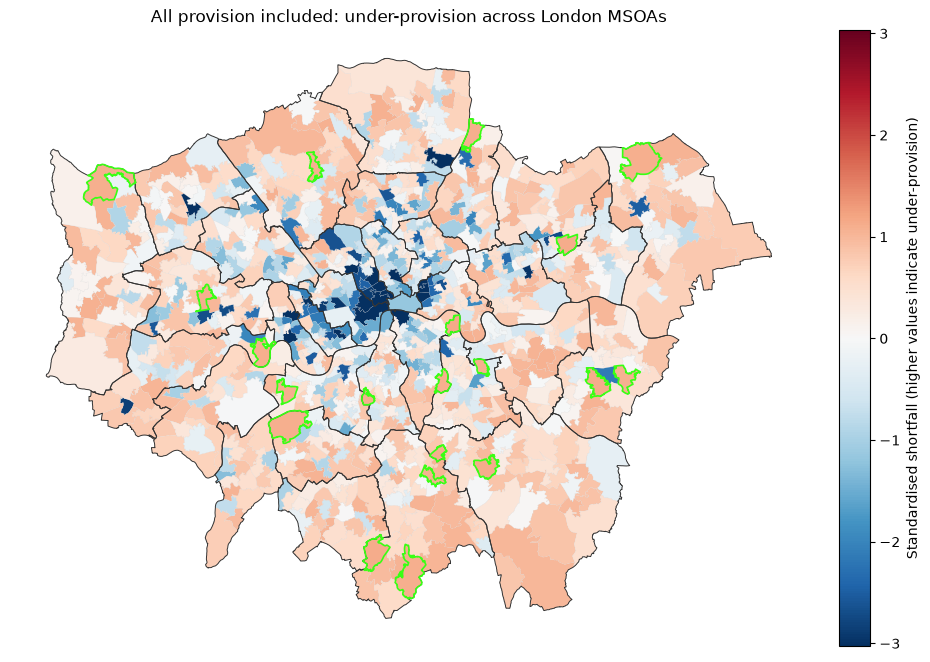

Saved to: ..\outputs\figures\msoa_all_provision_included_underprovision_2026-07-23.png


In [19]:
sensitivity_map_settings = [("Core only",
                             "core_standardised_shortfall",
                             "core_underprovision_rank"),
                             ("All provision included",
                              "all_standardised_shortfall",
                              "all_underprovision_rank")]

sensitivity_columns = ["core_standardised_shortfall",
                       "core_underprovision_rank",
                       "all_standardised_shortfall",
                       "all_underprovision_rank"]

sensitivity_map_data = (msoa_boundaries[["msoa_code","geometry"]]
                        .merge(analysis_data[["msoa_code"] + sensitivity_columns],
                               on="msoa_code",
                               how="left",
                               validate="one_to_one"))

sensitivity_colour_norm = primary_colour_norm

for definition, score_column, rank_column in sensitivity_map_settings:
    fig, axis = plt.subplots(figsize=(20, 8))

    sensitivity_map_data.plot(column=score_column,
                              cmap="RdBu_r",
                              norm=primary_colour_norm,
                              linewidth=0.1,
                              edgecolor="lightgrey",
                              ax=axis)

    borough_boundaries.boundary.plot(color="#333333", linewidth=0.7, ax=axis)

    highest_ranked = sensitivity_map_data[sensitivity_map_data[rank_column] <= 20]
    highest_ranked.boundary.plot(color="#39FF14", linewidth=1.2, ax=axis)

    colour_scale = plt.cm.ScalarMappable(norm=primary_colour_norm, cmap="RdBu_r")

    colour_bar = fig.colorbar(colour_scale, ax=axis, fraction=0.035, pad=0.02)
    colour_bar.set_label("Standardised shortfall (higher values indicate under-provision)")

    axis.set_title(f"{definition}: under-provision across London MSOAs")
    axis.axis("off")

    filename = definition.lower().replace(" ", "_")
    output_path = FIGURE_FOLDER / f"msoa_{filename}_underprovision_{DATA_DATE}.png"

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved to: {output_path}")

## Save final under-provision results

These results represent relative rankings rather than statistically significant under-provision. 

Because all 20 highest-ranked MSOAs have zero observed establishments, their rank order is determined by differences in model-expected provision.

In [13]:
result_columns = ["msoa_code",
                  "msoa_name",
                  "borough_code",
                  "borough_name",
                  "area_km2",
                  "population",
                  "transport_nodes",
                  "income_bhc",
                  "core_bakery_count",
                  "core_and_cafe_count",
                  "bakery_count",
                  "income_expected_core_bakery_count",
                  "income_expected_core_and_cafe_count",
                  "income_expected_bakery_count",
                  "core_raw_shortfall",
                  "core_standardised_shortfall",
                  "core_underprovision_percentile",
                  "core_underprovision_rank",
                  "core_top_decile",
                  "core_cafe_raw_shortfall",
                  "core_cafe_standardised_shortfall",
                  "core_cafe_underprovision_percentile",
                  "core_cafe_underprovision_rank",
                  "core_cafe_top_decile",
                  "all_raw_shortfall",
                  "all_standardised_shortfall",
                  "all_underprovision_percentile",
                  "all_underprovision_rank",
                  "all_top_decile"]

underprovision_results = (analysis_data[result_columns].copy())

UNDERPROVISION_RESULTS_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_underprovision_{DATA_DATE}.csv")
PRIMARY_TOP_AREAS_PATH = (TABLE_FOLDER / f"top_core_cafe_underprovided_msoas_{DATA_DATE}.csv")
SENSITIVITY_TOP_AREAS_PATH = (TABLE_FOLDER / f"top_sensitivity_underprovided_msoas_{DATA_DATE}.csv")
SCORE_SUMMARY_PATH = (TABLE_FOLDER / f"underprovision_score_summary_{DATA_DATE}.csv")

underprovision_results.to_csv(UNDERPROVISION_RESULTS_PATH, index=False, encoding="utf-8-sig")
primary_top_areas.to_csv(PRIMARY_TOP_AREAS_PATH, index=False, encoding="utf-8-sig")
sensitivity_top_areas.to_csv(SENSITIVITY_TOP_AREAS_PATH, index=False, encoding="utf-8-sig")
score_summary.to_csv(SCORE_SUMMARY_PATH, index=False, encoding="utf-8-sig")

print(f"Complete results saved to: {UNDERPROVISION_RESULTS_PATH}")
print(f"Primary ranking saved to: {PRIMARY_TOP_AREAS_PATH}")
print(f"Sensitivity rankings saved to: {SENSITIVITY_TOP_AREAS_PATH}")
print(f"Score summary saved to: {SCORE_SUMMARY_PATH}")

Complete results saved to: ..\outputs\models\london_msoa_bakery_underprovision_2026-07-23.csv
Primary ranking saved to: ..\outputs\tables\top_core_cafe_underprovided_msoas_2026-07-23.csv
Sensitivity rankings saved to: ..\outputs\tables\top_sensitivity_underprovided_msoas_2026-07-23.csv
Score summary saved to: ..\outputs\tables\underprovision_score_summary_2026-07-23.csv
